# Load the data

Loads in the dataset into our notebook and checks the first 5 rows to make sure it works

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv
from supabase import create_client

load_dotenv()

url = os.getenv("SUPABASE_URL")
key = os.getenv("SUPABASE_KEY")
supabase = create_client(url, key)

# Allows us to fetch more than the 1 000 row limit that SupaBase has
all_rows = []
step = 1000
start = 0

while True:
    res = (
        supabase.table("telco_churn")
        .select("*")
        .range(start, start + step - 1)
        .execute()
    )
    if not res.data:
        break
    all_rows.extend(res.data)
    start += step

df = pd.DataFrame(all_rows)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## EDA 

Exploratory Data Anaylsis, we're trying to grasp why some customers churn and why some choose to stay. Are there any possible correlations or causations?

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df['TotalCharges_clean'] = df['TotalCharges'].str.strip().replace('', '0.0').astype(float)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_clean']
num_summary = df[num_cols].describe().T
print("--- Numerical Summary ---")
print(num_summary)

churn_counts = df['Churn'].value_counts(normalize=True) * 100
print("\n--- Churn Rate ---")
print(churn_counts)

contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print("\n--- Churn by Contract (%) ---")
print(contract_churn)

internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100
print("\n--- Churn by Internet Service (%) ---")
print(internet_churn)

payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100
print("\n--- Churn by Payment Method (%) ---")
print(payment_churn)

--- Numerical Summary ---
                     count         mean          std    min     25%      50%  \
tenure              7043.0    32.371149    24.559481   0.00    9.00    29.00   
MonthlyCharges      7043.0    64.761692    30.090047  18.25   35.50    70.35   
TotalCharges_clean  7043.0  2279.734304  2266.794470   0.00  398.55  1394.55   

                        75%      max  
tenure                55.00    72.00  
MonthlyCharges        89.85   118.75  
TotalCharges_clean  3786.60  8684.80  

--- Churn Rate ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

--- Churn by Contract (%) ---
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858

--- Churn by Internet Service (%) ---
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.8927

C:\Users\OGK19\AppData\Local\Temp\ipykernel_15440\3249963248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", ax=axes[0, 0], palette=["#2b5c8f", "#d95f02"])
C:\Users\OGK19\AppData\Local\Temp\ipykernel_15440\3249963248.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


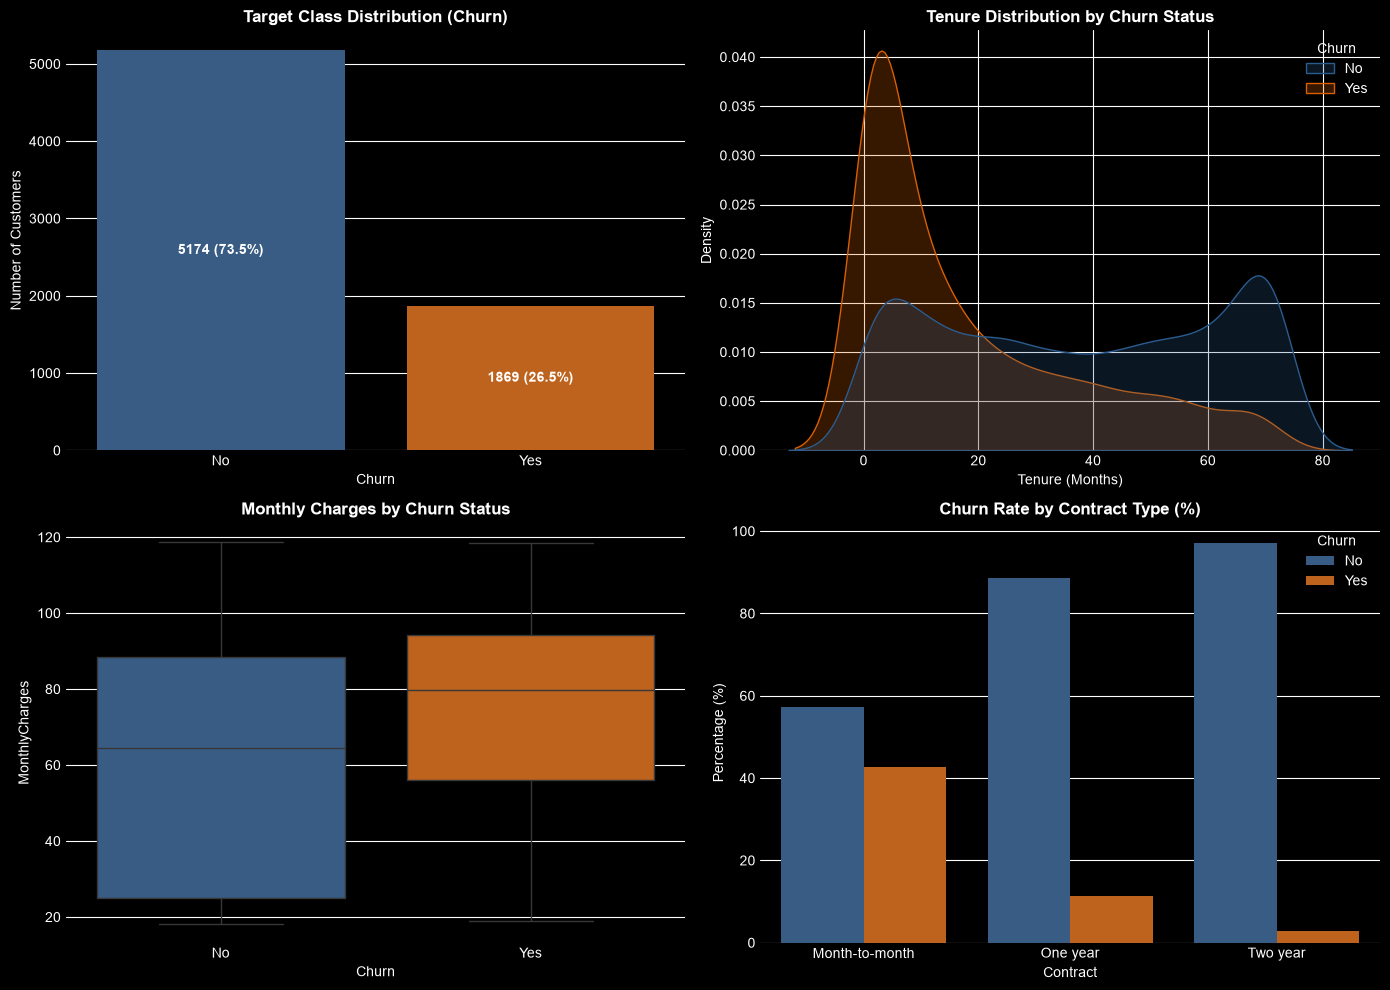

In [12]:
plt.style.use("dark_background")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x="Churn", ax=axes[0, 0], palette=["#2b5c8f", "#d95f02"])
axes[0, 0].set_title(
    "Target Class Distribution (Churn)", fontsize=12, fontweight="bold"
)
axes[0, 0].set_ylabel("Number of Customers")
for p in axes[0, 0].patches:
    axes[0, 0].annotate(
        f"{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)",
        (p.get_x() + p.get_width() / 2.0, p.get_height() / 2),
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

sns.kdeplot(
    data=df,
    x="tenure",
    hue="Churn",
    common_norm=False,
    fill=True,
    ax=axes[0, 1],
    palette=["#2b5c8f", "#d95f02"],
)
axes[0, 1].set_title(
    "Tenure Distribution by Churn Status", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Tenure (Months)")

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    ax=axes[1, 0],
    palette=["#2b5c8f", "#d95f02"],
)
axes[1, 0].set_title(
    "Monthly Charges by Churn Status", fontsize=12, fontweight="bold"
)

contract_data = (
    df.groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    .reset_index()
)
contract_data_melted = pd.melt(
    contract_data,
    id_vars="Contract",
    value_vars=["No", "Yes"],
    var_name="Churn",
    value_name="Proportion",
)
contract_data_melted["Percentage"] = contract_data_melted["Proportion"] * 100

sns.barplot(
    data=contract_data_melted,
    x="Contract",
    y="Percentage",
    hue="Churn",
    ax=axes[1, 1],
    palette=["#2b5c8f", "#d95f02"],
)
axes[1, 1].set_title(
    "Churn Rate by Contract Type (%)", fontsize=12, fontweight="bold"
)
axes[1, 1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

#### Conclusion to graph above

*Noteworthy:*

*  The longer the contract, the less likely someone is to churn 
*  Costumers mostly churn within the first 3-5 months
*  Nobody with monthly charges under ~$57 churns
*  26.5% (>1/4) of costumers churn

In [5]:
df_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges_clean']].copy()
df_corr['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("--- Correlation Matrix ---")
print(df_corr.corr()['Churn_num'])

print("\n--- Payment Method breakdown ---")
print(df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100)

print("\n--- Senior Citizen Churn Rate ---")
print(df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100)

print("\n--- Tech Support Churn Rate ---")
print(df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack() * 100)

--- Correlation Matrix ---
tenure               -0.352229
MonthlyCharges        0.193356
TotalCharges_clean   -0.198324
Churn_num             1.000000
Name: Churn_num, dtype: float64

--- Payment Method breakdown ---
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700

--- Senior Citizen Churn Rate ---
Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261

--- Tech Support Churn Rate ---
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341


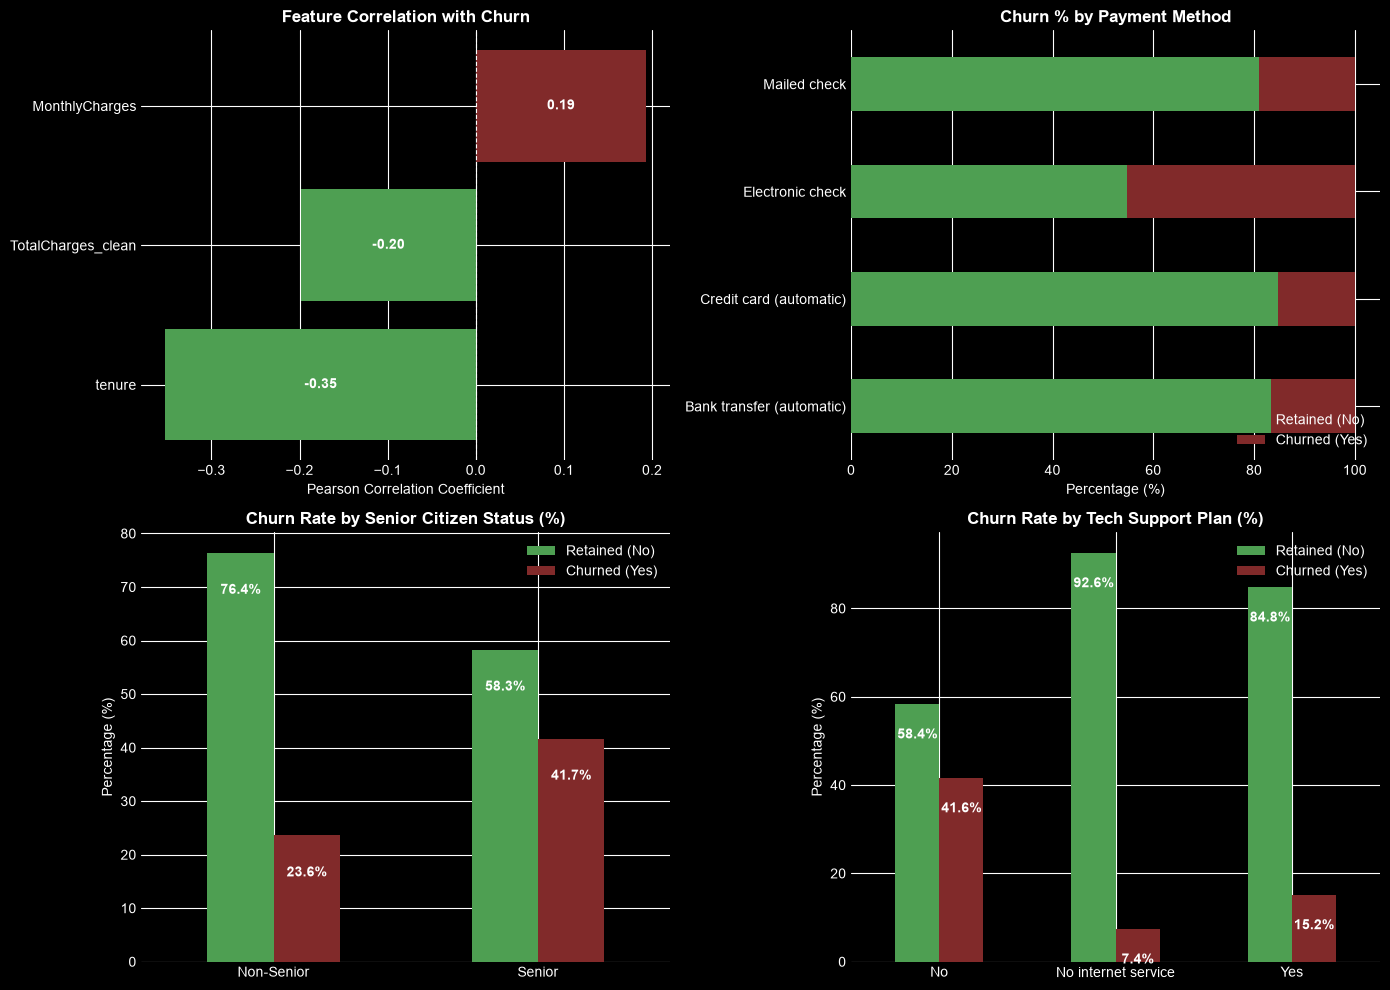

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("dark_background")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

color_retained = "#4e9f52"  # Bright Cyan / Light Blue
color_churned = "#812a2a"  # Neon Magenta / Pink

# ---------------------------------------------------------
# 1. Feature Correlations with Churn
# ---------------------------------------------------------
df_corr = df[["tenure", "MonthlyCharges", "TotalCharges_clean"]].copy()
df_corr["Churn_num"] = df["Churn"].map({"Yes": 1, "No": 0})
corr = df_corr.corr()["Churn_num"].drop("Churn_num").sort_values()

colors = [color_retained if x < 0 else color_churned for x in corr.values]
axes[0, 0].barh(corr.index, corr.values, color=colors)
axes[0, 0].axvline(0, color="white", linewidth=0.8, linestyle="--")
axes[0, 0].set_title(
    "Feature Correlation with Churn", fontsize=12, fontweight="bold"
)
axes[0, 0].set_xlabel("Pearson Correlation Coefficient")

for idx, val in enumerate(corr.values):
    axes[0, 0].text(
        val / 2,
        idx,
        f"{val:.2f}",
        va="center",
        ha="center",
        color="white",
        fontweight="bold",
    )

# ---------------------------------------------------------
# 2. Payment Method Breakdown
# ---------------------------------------------------------
pm_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)
pm_churn.plot(
    kind="barh",
    stacked=True,
    ax=axes[0, 1],
    color=[color_retained, color_churned],
)
axes[0, 1].set_title(
    "Churn % by Payment Method", fontsize=12, fontweight="bold"
)
axes[0, 1].set_xlabel("Percentage (%)")
axes[0, 1].set_ylabel("")
axes[0, 1].legend(["Retained (No)", "Churned (Yes)"], loc="lower right")

# ---------------------------------------------------------
# 3. Senior Citizen Churn Rate
# ---------------------------------------------------------
df["SeniorLabel"] = df["SeniorCitizen"].map({0: "Non-Senior", 1: "Senior"})
sc_churn = (
    df.groupby("SeniorLabel")["Churn"].value_counts(normalize=True).unstack()
    * 100
)
sc_churn.plot(
    kind="bar",
    stacked=False,
    ax=axes[1, 0],
    color=[color_retained, color_churned],
    rot=0,
)
axes[1, 0].set_title(
    "Churn Rate by Senior Citizen Status (%)", fontsize=12, fontweight="bold"
)
axes[1, 0].set_ylabel("Percentage (%)")
axes[1, 0].set_xlabel("")
axes[1, 0].legend(["Retained (No)", "Churned (Yes)"])

for p in axes[1, 0].patches:
    if p.get_height() > 0:
        axes[1, 0].annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width() / 2.0, p.get_height() - 7),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )

# ---------------------------------------------------------
# 4. Tech Support Churn Rate
# ---------------------------------------------------------
ts_churn = (
    df.groupby("TechSupport")["Churn"].value_counts(normalize=True).unstack()
    * 100
)
ts_churn.plot(
    kind="bar",
    stacked=False,
    ax=axes[1, 1],
    color=[color_retained, color_churned],
    rot=0,
)
axes[1, 1].set_title(
    "Churn Rate by Tech Support Plan (%)", fontsize=12, fontweight="bold"
)
axes[1, 1].set_ylabel("Percentage (%)")
axes[1, 1].set_xlabel("")
axes[1, 1].legend(["Retained (No)", "Churned (Yes)"])

for p in axes[1, 1].patches:
    if p.get_height() > 0:
        axes[1, 1].annotate(
            f"{p.get_height():.1f}%",
            (p.get_x() + p.get_width() / 2.0, p.get_height() - 7),
            ha="center",
            va="center",
            color="white",
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

#### Conclussion to the graph above 

*Noteworthy* 

* TOP-LEFT: As the monthly charges increase, the positive correlation to churning increases
* TOP-RIGHT: Manual Electronic Checks increases the likelyhood of churning
* BOTTOM-LEFT: Senior citizens arae more likely to Churn
* BOTTOM-RIGHT: No included technical support plans leads to higher churn rates, while included techincal support causes a noticiable decrease in churn rates. No Internet service, the middle graph, has the lowest churn rate due to costumers using simpler services such as landlines only and thus are less prone to experiencing frustrating issues